# ZueriWieNeu - Understanding Infrastructure Complaints in Zurich

<div class="page-subtitle">
Raphael Knecht | SDS210 Programming with Spatial Data | Final Project | 22.05.2026
</div>

This notebook analyses public ZueriWieNeu reports in the City of Zurich. The goal is to understand where reports are concentrated, which issue categories dominate, how reporting changes over time, and whether selected reporting patterns differ by neighbourhood.

## 1. Imports and Project Folders

This first section loads the libraries and defines the project folders.


In [1]:
from pathlib import Path

from cmcrameri import cm 
from shapely.geometry import box

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Resolve the project root relative to the notebook location to avoid
# hard-coded machine-specific paths
PROJECT_DIR = Path.cwd().parent

DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"

# Create the output directory if it does not exist so exports can be
# written without requiring manual setup
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

reports_path = DATA_DIR / "stzh.zwn_meldungen_p.csv"
neighbourhoods_path = DATA_DIR / "zh_neighbourhoods.gpkg"

print("Project folder:", PROJECT_DIR)
print("Reports file exists:", reports_path.exists())
print("Neighbourhood file exists:", neighbourhoods_path.exists())

Project folder: /Users/raphi.knecht/Documents/Studium/07_FS2026/sds210-final
Reports file exists: True
Neighbourhood file exists: True


## 2. Load and Validate the Reports Table

The reports CSV is treated as read-only raw data. The notebook parses date columns immediately and checks that the columns required for the analysis are present before any cleaning or plotting happens.


In [3]:
required_report_columns = [
    "objectid",
    "service_request_id",
    "requested_datetime",
    "agency_sent_datetime",
    "e",
    "n",
    "service_name",
    "status",
    "title",
    "detail",
    "description",
    "url",
]

# Parse timestamps on import so temporal variables can be derived without
# additional type conversion during the analysis workflow
reports_raw = pd.read_csv(
    reports_path,
    usecols=lambda column: column in required_report_columns,
    parse_dates=["requested_datetime"],
)

# Fail early if the source schema differs from the version used to develop
# the workflow, as downstream cleaning and mapping depend on these fields
missing_report_columns = sorted(set(required_report_columns) - set(reports_raw.columns))
if missing_report_columns:
    raise KeyError(
        f"Reports table is missing required columns: {missing_report_columns}. "
        "These fields are needed for cleaning, mapping, and summary analysis."
    )

# An empty dataset usually indicates a loading or export problem and would
# invalidate all subsequent summaries and spatial analyses
if len(reports_raw) == 0:
    raise ValueError(
        f"Reports table is empty after loading '{reports_path}'. "
        "The analysis requires at least one report row."
    )

print("Rows and columns:", reports_raw.shape)
display(reports_raw.head(3))


Rows and columns: (73306, 12)


,objectid,service_request_id,requested_datetime,agency_sent_datetime,e,n,service_name,status,title,detail,description,url
0,1,1,2013-03-14 15:16:15,2013-04-04T07:25:05,2678968,1247548,Strasse/Trottoir/Platz,fixed - council,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1
1,2,2,2013-03-14 15:17:57,2013-03-26T14:05:05,2680746,1249916,Strasse/Trottoir/Platz,fixed - council,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2
2,3,4,2013-03-15 09:14:16,2013-03-15T09:55:05,2684605,1251431,Strasse/Trottoir/Platz,fixed - council,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4


In [4]:
display(reports_raw.dtypes.to_frame("dtype"))

,dtype
objectid,int64
service_request_id,int64
requested_datetime,datetime64[us]
agency_sent_datetime,str
e,int64
n,int64
service_name,str
status,str
title,str
detail,str


## 3. Select and Prepare Analysis Variables

Only the variables needed for this notebook are kept. Coordinates are converted to numeric values, incomplete rows that cannot be mapped are removed, and time variables are derived from the request timestamp.


In [5]:
reports = reports_raw[required_report_columns].copy()

# Convert coordinate fields to numeric values; invalid entries become NaN so
# they can be identified and removed before spatial operations
reports["e"] = pd.to_numeric(reports["e"], errors="coerce") # errors="coerce" converts invalid parsing to NaN
reports["n"] = pd.to_numeric(reports["n"], errors="coerce")

# Records without valid coordinates or timestamps cannot be assigned to a
# location or time period and are excluded from subsequent analyses
reports = reports.dropna(subset=["e", "n", "requested_datetime"])

reports["year"] = reports["requested_datetime"].dt.year
reports["month"] = reports["requested_datetime"].dt.month
reports["weekday"] = reports["requested_datetime"].dt.day_name()


analysis_start = reports["requested_datetime"].min().date()
analysis_end = reports["requested_datetime"].max().date()
date_range_label = f"{analysis_start:%d.%m.%Y} - {analysis_end:%d.%m.%Y}"

print("Rows after cleaning:", len(reports))
print("Analysis period:", date_range_label)
display(reports.head(3))

Rows after cleaning: 73306
Analysis period: 14.03.2013 - 20.05.2026


,objectid,service_request_id,requested_datetime,agency_sent_datetime,e,n,service_name,status,title,detail,description,url,year,month,weekday
0,1,1,2013-03-14 15:16:15,2013-04-04T07:25:05,2678968,1247548,Strasse/Trottoir/Platz,fixed - council,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,2013,3,Thursday
1,2,2,2013-03-14 15:17:57,2013-03-26T14:05:05,2680746,1249916,Strasse/Trottoir/Platz,fixed - council,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,2013,3,Thursday
2,3,4,2013-03-15 09:14:16,2013-03-15T09:55:05,2684605,1251431,Strasse/Trottoir/Platz,fixed - council,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,2013,3,Friday


In [6]:
# Check for missing values in the cleaned reports data
missing_values = reports.isna().sum().sort_values(ascending=False)
display(missing_values.to_frame("missing_values"))

,missing_values
agency_sent_datetime,833
detail,2
title,2
requested_datetime,0
e,0
service_request_id,0
objectid,0
service_name,0
n,0
status,0


## 4. Load and Validate the Neighbourhood Boundaries

The spatial analysis uses Zurich statistical neighbourhood polygons in Swiss coordinates (`EPSG:2056`). The CRS and layer name are checked explicitly because a wrong projection or wrong layer would change the spatial join result.


In [7]:
# Verify the expected layer exists because GeoPackage layer names can vary
# between dataset releases and exports
available_layers = gpd.list_layers(neighbourhoods_path)
display(available_layers)

neighbourhoods_layer = "stzh.adm_statistische_quartiere_v"
if neighbourhoods_layer not in set(available_layers["name"]):
    raise KeyError(
        f"GeoPackage '{neighbourhoods_path}' does not contain the expected layer "
        f"'{neighbourhoods_layer}'. The neighbourhood polygons cannot be loaded."
    )

,name,geometry_type
0,stzh.adm_statistische_quartiere_b_p,Unknown
1,stzh.adm_statistische_quartiere_v,Unknown
2,stzh.adm_statistische_quartiere_map,Unknown


In [8]:
neighbourhoods_gdf = gpd.read_file(
    neighbourhoods_path,
    layer=neighbourhoods_layer,
)

# Fail early if the layer schema differs from the version used to develop
# the workflow, as the spatial join depends on these attributes
missing_neighbourhood_columns = sorted(
    set(["qname", "qnr", "geometry"]) - set(neighbourhoods_gdf.columns)
)
if missing_neighbourhood_columns:
    raise KeyError(
        f"Neighbourhood layer '{neighbourhoods_layer}' is missing required columns: "
        f"{missing_neighbourhood_columns}. These fields are needed for the spatial join."
    )

# A spatial join is only meaningful if neighbourhood polygons are present
if len(neighbourhoods_gdf) == 0:
    raise ValueError(
        f"Neighbourhood layer '{neighbourhoods_layer}' is empty. "
        "The spatial join requires at least one polygon."
    )

# Coordinate reference information is required to ensure spatial operations
# are performed in the correct location and units
if neighbourhoods_gdf.crs is None:
    raise ValueError(
        f"Neighbourhood layer '{neighbourhoods_layer}' has no CRS. "
        "The analysis assumes Swiss projected coordinates (EPSG:2056)."
    )

# EPSG:2056 is required because the report coordinates are Swiss LV95 eastings/northings
if neighbourhoods_gdf.crs.to_string() != "EPSG:2056":
    raise ValueError(
        f"Neighbourhood layer '{neighbourhoods_layer}' has CRS {neighbourhoods_gdf.crs}, "
        "but the analysis assumes EPSG:2056."
    )

neighbourhoods_gdf = neighbourhoods_gdf.rename(
    columns={"qname": "neighbourhood", "qnr": "neighbourhood_id"}
)

print("Rows and columns:", neighbourhoods_gdf.shape)
print("CRS:", neighbourhoods_gdf.crs)
display(neighbourhoods_gdf.head(3))

Rows and columns: (34, 7)
CRS: EPSG:2056


,objid,objectid,neighbourhood,neighbourhood_id,kname,knr,geometry
0,1,1,Alt-Wiedikon,31,Kreis 3,3,"POLYGON ((2680606.662 1247034.584, 2680626.356..."
1,10,2,Witikon,74,Kreis 7,7,"POLYGON ((2685858.632 1246502.629, 2685860.738..."
2,11,3,Langstrasse,42,Kreis 4,4,"POLYGON ((2681313.304 1248613.857, 2681459.605..."


## 5. Convert Reports to Spatial Points

The report coordinates are LV95 eastings and northings, so the point layer is created directly in `EPSG:2056`. Before joining, the notebook checks CRS equality and spatial overlap to avoid silently producing an empty spatial result.


In [9]:
# Report coordinates are stored as LV95 eastings/northings, so points can be
# created directly in EPSG:2056 without reprojection
reports_gdf = gpd.GeoDataFrame(
    reports,
    geometry=gpd.points_from_xy(reports["e"], reports["n"]),
    crs="EPSG:2056",
)

if reports_gdf.crs != neighbourhoods_gdf.crs:
    raise ValueError(
        f"CRS mismatch before spatial join: reports_gdf has {reports_gdf.crs}, "
        f"but neighbourhoods_gdf has {neighbourhoods_gdf.crs}. Both datasets must use the same CRS."
    )

reports_extent = box(*reports_gdf.total_bounds)
neighbourhoods_extent = box(*neighbourhoods_gdf.total_bounds)
# Check spatial overlap to catch CRS or coordinate errors before the join silently fails
if not reports_extent.intersects(neighbourhoods_extent):
    raise ValueError(
        "Report points and neighbourhood polygons do not overlap in space. "
        "Check the input extents and coordinate reference systems before running the spatial join."
    )

print("Reports CRS:", reports_gdf.crs)
display(reports_gdf.head(3))

Reports CRS: EPSG:2056


,objectid,service_request_id,requested_datetime,agency_sent_datetime,e,n,service_name,status,title,detail,description,url,year,month,weekday,geometry
0,1,1,2013-03-14 15:16:15,2013-04-04T07:25:05,2678968,1247548,Strasse/Trottoir/Platz,fixed - council,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,2013,3,Thursday,POINT (2678968 1247548)
1,2,2,2013-03-14 15:17:57,2013-03-26T14:05:05,2680746,1249916,Strasse/Trottoir/Platz,fixed - council,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,2013,3,Thursday,POINT (2680746 1249916)
2,3,4,2013-03-15 09:14:16,2013-03-15T09:55:05,2684605,1251431,Strasse/Trottoir/Platz,fixed - council,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,2013,3,Friday,POINT (2684605 1251431)


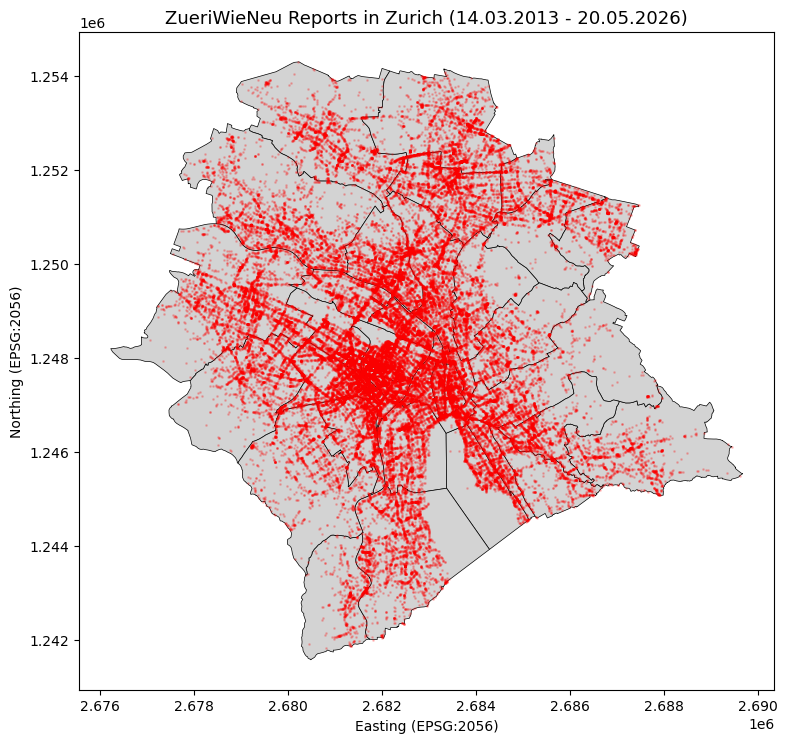

In [10]:
# Visual sanity check: report locations should fall within Zurich and show
# plausible spatial clustering before proceeding with spatial analysis
fig, ax = plt.subplots(figsize=(8, 8))

neighbourhoods_gdf.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="black",
    linewidth=0.5,
    # Draw polygons beneath report points to keep observations visible
    zorder=1,
)
reports_gdf.plot(
    ax=ax,
    color="red",
    markersize=1,
    alpha=0.2,
    zorder=2,
)

ax.set_title(f"ZueriWieNeu Reports in Zurich ({date_range_label})", fontsize=13)
ax.set_xlabel("Easting (EPSG:2056)")
ax.set_ylabel("Northing (EPSG:2056)")
plt.tight_layout()
plt.show()

fig.savefig(OUTPUT_DIR / "reports_map.png", dpi=300, bbox_inches="tight")

The report points fall within the Zurich neighbourhood polygons, so the coordinate interpretation as `EPSG:2056` is plausible.


## 6. Spatial Join

Each report point is assigned to the neighbourhood polygon that contains it. The `within` predicate is used because the report locations are points and the neighbourhood layer contains polygons.


In [11]:
# Use 'within' because each report point is expected to fall inside exactly
# one neighbourhood polygon
joined_gdf = gpd.sjoin(
    reports_gdf,
    neighbourhoods_gdf[["neighbourhood", "neighbourhood_id", "geometry"]],
    # Use left join to keep all reports and identify unmatched points with NaN neighbourhoods
    how="left",
    predicate="within",
)

unmatched_reports = joined_gdf["neighbourhood"].isna().sum()

# Treat unmatched reports as an error because missing neighbourhood assignments
# would bias neighbourhood-level rankings
if unmatched_reports > 0:
    raise ValueError(
        f"Spatial join left {unmatched_reports} report points without a neighbourhood. "
        "Every report is expected to fall within one Zurich neighbourhood polygon."
    )

print("Reports with neighbourhood:", joined_gdf["neighbourhood"].notna().sum())
print("Reports without neighbourhood:", unmatched_reports)
display(
    joined_gdf[
        ["objectid", "requested_datetime", "service_name", "status", "neighbourhood"]
    ].head(5)
)

Reports with neighbourhood: 73306
Reports without neighbourhood: 0


,objectid,requested_datetime,service_name,status,neighbourhood
0,1,2013-03-14 15:16:15,Strasse/Trottoir/Platz,fixed - council,Albisrieden
1,2,2013-03-14 15:17:57,Strasse/Trottoir/Platz,fixed - council,Höngg
2,3,2013-03-15 09:14:16,Strasse/Trottoir/Platz,fixed - council,Saatlen
3,4,2013-03-15 09:17:15,Strasse/Trottoir/Platz,fixed - council,Wipkingen
4,5,2013-03-15 10:36:53,Abfall/Sammelstelle,fixed - council,City


## Research Question 1: Which Neighbourhoods Receive the Most Reports?

Raw report counts show where ZueriWieNeu is used most often. These counts may reflect actual infrastructure problems, population density, centrality, or different reporting habits, so they should be interpreted as reporting intensity rather than a direct measure of urban quality.


In [12]:
reports_per_neighbourhood = (
    joined_gdf["neighbourhood"]
    .value_counts()
    .rename_axis("neighbourhood")
    .reset_index(name="report_count")
)

display(reports_per_neighbourhood.head(10))

,neighbourhood,report_count
0,Langstrasse,6222
1,Sihlfeld,5277
2,Altstetten,4140
3,Unterstrass,3612
4,Wipkingen,3336
5,Höngg,3115
6,Oerlikon,3001
7,Hard,2887
8,Wollishofen,2865
9,Enge,2769


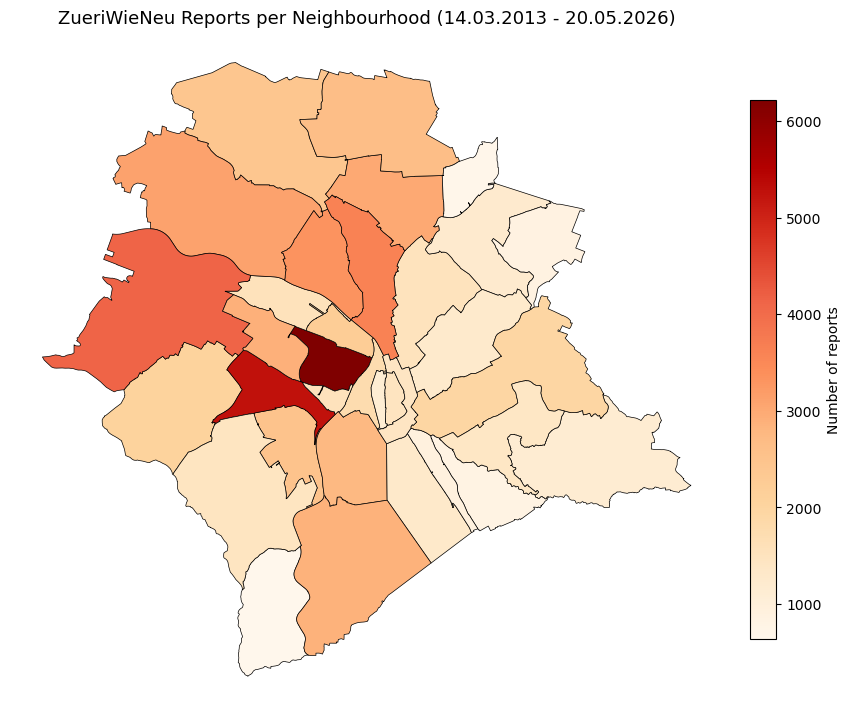

In [13]:
# Assign report counts to neighbourhood polygons for choropleth mapping;
# neighbourhoods without reports are represented as zero rather than missing
neighbourhood_counts_gdf = neighbourhoods_gdf.merge(
    reports_per_neighbourhood,
    on="neighbourhood",
    how="left",
)
neighbourhood_counts_gdf["report_count"] = neighbourhood_counts_gdf["report_count"].fillna(0)

fig, ax = plt.subplots(figsize=(9, 8))

neighbourhood_counts_gdf.plot(
    ax=ax,
    column="report_count",
    cmap="OrRd",
    legend=True,
    legend_kwds={
        "label": "Number of reports",
        "orientation": "vertical",
        "shrink": 0.7,  # Adjust legend size
        "pad": 0.03, # Adjust padding to prevent legend from overlapping the map
    },
    edgecolor="black",
    linewidth=0.5,
)

ax.set_title(f"ZueriWieNeu Reports per Neighbourhood ({date_range_label})", fontsize=13)
ax.axis("off")
plt.tight_layout() # prevent title and legend from overlapping the map
plt.show()

fig.savefig(OUTPUT_DIR / "reports_per_neighbourhood_map.png", dpi=300, bbox_inches="tight")

**Answer:** Langstrasse has the highest number of reports with 6'222 reports, followed by Sihlfeld with 5'277 and Altstetten with 4'140. The highest raw counts are concentrated in central and dense neighbourhoods, so later density calculations are needed to separate high activity from large area or high population exposure. At the same time, it seems plausable that an area like Langstrasse, which is known for its nightlife and high foot traffic, would have more reports due to more interactions with public infrastructure.

## Research Question 2: Which Problem Categories Are Most Common City-Wide?

The `service_name` field stores the issue category. A simple frequency count is the most direct way to identify the dominant types of reported problems.


In [14]:
category_counts = reports["service_name"].value_counts()
display(category_counts)

service_name
Abfall/Sammelstelle          27653
Signalisation/Lichtsignal    11052
Strasse/Trottoir/Platz        9918
Grünflächen/Spielplätze       7309
Beleuchtung/Uhren             5429
Allgemein                     4019
Graffiti                      3809
VBZ/ÖV                        1901
Brunnen/Hydranten             1314
Schädlinge                     902
Name: count, dtype: int64

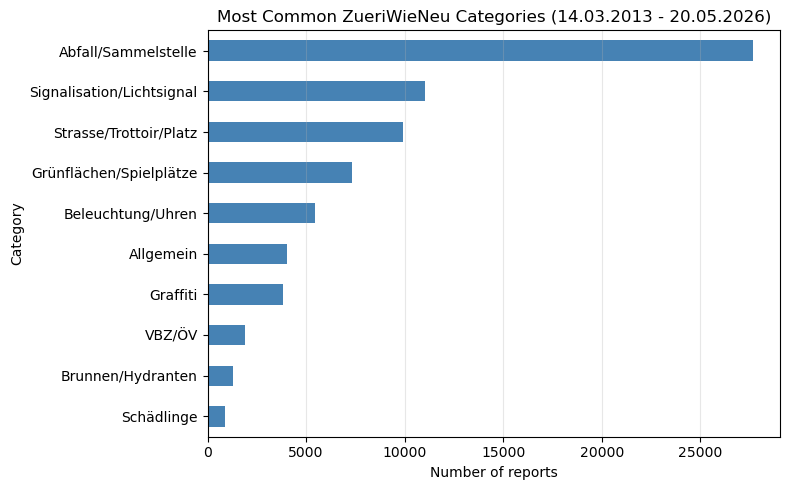

In [15]:
# Restrict the chart to the ten most common categories to keep labels readable
# and focus on the dominant reporting patterns
ax = category_counts.head(10).plot(
    kind="barh",
    figsize=(8, 5),
    title=f"Most Common ZueriWieNeu Categories ({date_range_label})",
    xlabel="Number of reports",
    ylabel="Category",
    color="steelblue",
)
ax.invert_yaxis() # Highest counts on top
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

**Answer:** `Abfall/Sammelstelle` is by far the most common category with 27'653 reports. It is followed by `Signalisation/Lichtsignal` with 11'052 reports and `Strasse/Trottoir/Platz` with 9'918 reports. Waste and collection-point issues therefore dominate the city-wide reporting profile.

## Research Question 3: Are Certain Issue Types Concentrated in Particular Neighbourhoods?

To compare neighbourhoods fairly, this section uses category shares within each neighbourhood rather than only raw counts. This avoids treating a large neighbourhood with many reports as automatically more specialised.


In [16]:
# Compare issue types within neighbourhoods rather than only citywide totals
category_by_neighbourhood = (
    joined_gdf.groupby(["neighbourhood", "service_name"])
    .size()
    .reset_index(name="report_count")
)

# Calculate total reports per neighbourhood to compute category shares
neighbourhood_totals = (
    joined_gdf.groupby("neighbourhood")
    .size()
    .reset_index(name="neighbourhood_total")
)

# Merge the total report counts back to the category-by-neighbourhood DataFrame to calculate shares
category_by_neighbourhood = category_by_neighbourhood.merge(
    neighbourhood_totals,
    on="neighbourhood",
)
# Use percentages so small and large neighbourhoods can be compared more fairly
category_by_neighbourhood["share_percent"] = (
    category_by_neighbourhood["report_count"]
    / category_by_neighbourhood["neighbourhood_total"]
    * 100
)

# Focus on common categories to avoid over-interpreting patterns based on rare
# issue types with very few reports
common_categories = category_counts.head(6).index
common_category_patterns = category_by_neighbourhood[
    category_by_neighbourhood["service_name"].isin(common_categories)
].copy()

# Select the strongest neighbourhood-level concentrations for each common
# category as candidate hotspots
strongest_patterns = (
    common_category_patterns.sort_values("share_percent", ascending=False)
    .groupby("service_name")
    .head(3)
)

display(
    strongest_patterns[
        ["service_name", "neighbourhood", "report_count", "share_percent"]
    ].round(1)
)

,service_name,neighbourhood,report_count,share_percent
160,Abfall/Sammelstelle,Langstrasse,3880,62.4
300,Abfall/Sammelstelle,Werd,936,60.7
270,Abfall/Sammelstelle,Sihlfeld,3167,60.0
85,Grünflächen/Spielplätze,Friesenberg,418,28.8
68,Strasse/Trottoir/Platz,Escher Wyss,394,25.1
138,Strasse/Trottoir/Platz,Hochschulen,312,21.8
48,Strasse/Trottoir/Platz,City,382,21.8
67,Signalisation/Lichtsignal,Escher Wyss,341,21.7
137,Signalisation/Lichtsignal,Hochschulen,309,21.6
47,Signalisation/Lichtsignal,City,375,21.4


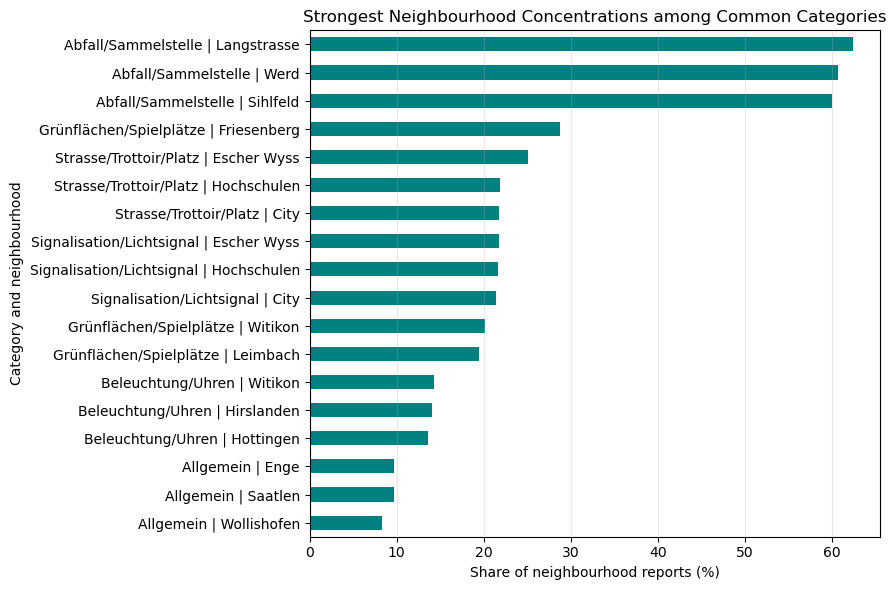

In [17]:
# Visualise category concentrations using percentage shares rather than raw
# counts so neighbourhoods with different reporting volumes remain comparable
plot_patterns = strongest_patterns.copy()
plot_patterns["label"] = (
    plot_patterns["service_name"] + " | " + plot_patterns["neighbourhood"]
)

ax = plot_patterns.sort_values("share_percent").plot(
    x="label",
    y="share_percent",
    kind="barh",    # horizontal bars
    figsize=(9, 6),
    legend=False,
    color="teal",
    title="Strongest Neighbourhood Concentrations among Common Categories",
    xlabel="Share of neighbourhood reports (%)",
    ylabel="Category and neighbourhood",
)
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

**Answer:** Waste-related reports are especially concentrated in Langstrasse, Werd, and Sihlfeld, where `Abfall/Sammelstelle` makes up about 61-62%, 61%, and 60% of neighbourhood reports respectively. Some other categories show local concentrations too, such as `Grünflächen/Spielplätze` in Friesenberg and `Strasse/Trottoir/Platz` in Escher Wyss, but the strongest pattern is the dominance of waste reports in selected central neighbourhoods. Once again, Langstrasse being a nightlife and high foot traffic area may explain the high share of waste-related reports, as more people interact with public infrastructure and generate more waste in that area.


## Research Question 4: How Does Reporting Vary over Time?

The parsed request timestamp allows yearly and monthly aggregation. The year plot shows long-term reporting activity, while the month plot gives a simple seasonal overview.


In [18]:
reports_per_year = reports.groupby("year").size().reset_index(name="report_count")
display(reports_per_year)

,year,report_count
0,2013,2901
1,2014,2139
2,2015,1943
3,2016,2307
4,2017,2869
5,2018,3724
6,2019,5243
7,2020,4802
8,2021,5783
9,2022,6828


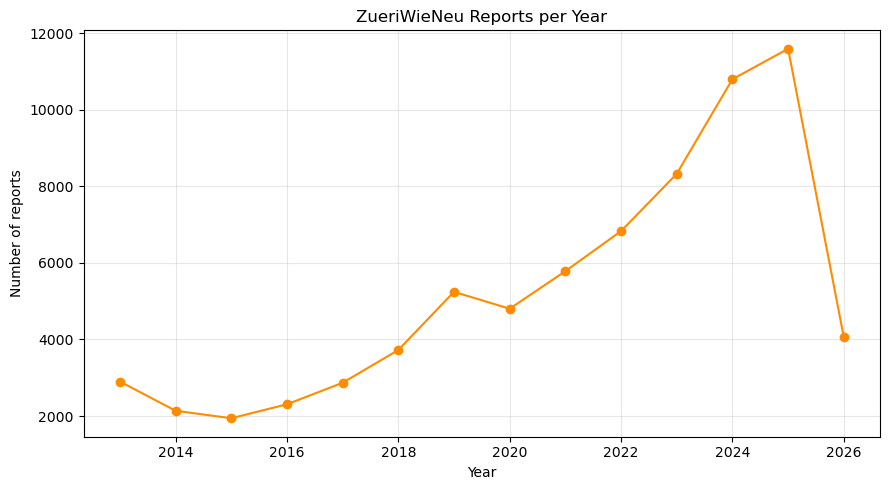

In [19]:
ax = reports_per_year.plot(
    x="year",
    y="report_count",
    figsize=(9, 5),
    marker="o",
    legend=False,
    title="ZueriWieNeu Reports per Year",
    xlabel="Year",
    ylabel="Number of reports",
    color="darkorange",
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Answer:** Annual reporting increased strongly over time. The lowest complete-year value is 2015 with 1,943 reports, while 2025 has the highest count with 11,588 reports. The 2026 value is lower because the dataset only runs until 20 May 2026, so it is not comparable to full years.


,month,report_count
0,1,5161
1,2,4756
2,3,5624
3,4,6650
4,5,7109
5,6,6842
6,7,7291
7,8,7293
8,9,6505
9,10,6102


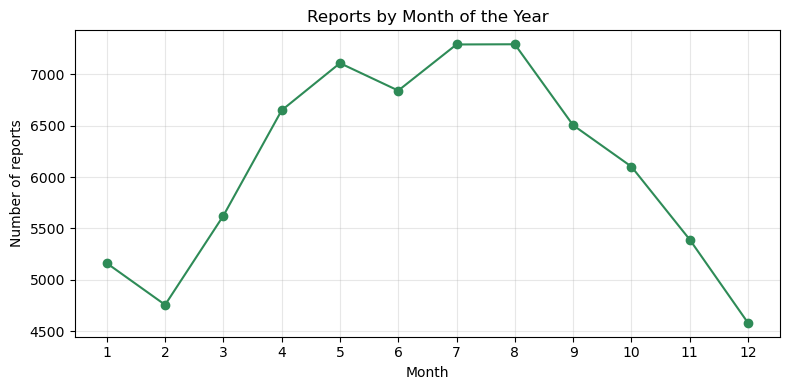

In [20]:
# Aggregate by month number to explore broad seasonal patterns across all years
reports_per_month = reports.groupby("month").size().reset_index(name="report_count")
display(reports_per_month)

ax = reports_per_month.plot(
    x="month",
    y="report_count",
    figsize=(8, 4),
    marker="o",
    legend=False,
    title="Reports by Month of the Year",
    xlabel="Month",
    ylabel="Number of reports",
    color="seagreen",
)
ax.set_xticks(range(1, 13))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Answer:** Reporting is highest in late summer, with August (7'293 reports) and July (7'291 reports) slightly above the other months. December (4'581) and February (4'756) have the fewest reports, suggesting lower winter reporting activity or fewer visible/reportable outdoor issues. The general trend of higher reporting in warmer months is consistent with more outdoor activity and more visible infrastructure problems during that time.


## Research Question 5: Are Strongly Worded Reports Spatially Clustered?

This section tries to identify reports that contain unusually strong or emotional language.
To do this, the analysis uses regular expressions (regex), which are text-search patterns.

For example:

- `dringend|sofort|umgehend`

matches:
- "dringend"
- OR "sofort"
- OR "umgehend"

The `|` symbol means "or".

Some regex patterns also detect different grammatical forms of a word.

For example:

- `verletz\w*`

matches:
- "verletzt"
- "Verletzung"
- "Verletzungen"

The `\w*` part means that additional letters after the word stem are allowed.

The analysis also searches for repeated exclamation marks (`!!`) and words written in ALL CAPS,
which may indicate emotional emphasis or urgency.

Reports containing one or more of these signals are marked as "strongly worded".

This approach was created for exploratory analysis and should not be understood as a precise
measurement of emotion. **The structure and regex patterns for this section were developed with
the assistance of ChatGPT-5.**

In [21]:
# This keyword list is an exploratory proxy for frustration and urgency in
# citizen reports, not a validated sentiment-analysis model
strong_wording_pattern = (
    r"immer wieder|schon wieder|wiederholt|ständig|dauernd|mehrmals|erneut|"
    r"seit wochen|seit monaten|seit jahren|seit langem|seit längerem|"
    r"dringend(?:st)?|sofort|umgehend|schnellstmöglich|unverzüglich|"
    r"baldmöglichst|bitte dringend|muss dringend|bitte sofort|"
    r"endlich|bitte endlich|muss endlich|wird zeit|höchste zeit|wann wird|"
    r"gefährlich\w*|gefaehrlich\w*|gefährd\w*|gefaehrd\w*|"
    r"unfall\w*|beinahe[- ]?unfall|sturz\w*|stolper\w*|verletz\w*|"
    r"\bgefahr\b|unfallgefahr|sturzgefahr|stolpergefahr|verletzungsgefahr|"
    r"rutschgefahr|absturzgefahr|kollisionsgefahr|lebensgefahr|"
    r"lebensgefährlich|sicherheitsrisiko|unfallrisiko|verletzungsrisiko|akut\w*|"
    r"inakzeptabel|nicht akzeptabel|unakzeptabel|unhaltbar\w*|unzumutbar\w*|"
    r"zumutung|geht gar nicht|katastroph\w*|skandal\w*|sauerei|"
    r"riesensauerei|ärger\w*|aerger\w*|nerv\w*|mühsam|muehsam|"
    r"lästig|laestig|frust\w*|schlimm|schrecklich|furchtbar|chaos|"
    r"leider|problematisch|kritisch|prekär|prekaer|unsicher|mangelhaft|"
    r"stinkt|gestank|ekel\w*|verdreckt|dreckig|verschmutzt|schmutzig"
)

# Missing descriptions are treated as empty text so reports are not excluded
# from the wording analysis solely because the detail field is absent

# Convert the 'detail' column to string and fill NaN values with empty strings
# to ensure text analysis can be performed without errors due to missing values
joined_gdf["detail_text"] = joined_gdf["detail"].fillna("").astype(str) 
joined_gdf["strong_wording_keyword"] = joined_gdf["detail_text"].str.contains(
    strong_wording_pattern,
    case=False,
    regex=True,
)   # Create a boolean column indicating whether the detail text contains any of the strong wording keywords,
    # ignoring case and treating missing values as empty strings to avoid false negatives in the analysis

joined_gdf["many_exclamation_marks"] = joined_gdf["detail_text"].str.contains(
    r"!{2,}",
    regex=True,
) # Create a boolean column indicating whether the detail text contains two or more exclamation marks
joined_gdf["capitalised_emphasis"] = joined_gdf["detail_text"].str.contains(
    r"\b[A-ZÄÖÜ]{3,}\b",
    regex=True,
) # Create a boolean column indicating whether the detail text contains any fully capitalised words of 3 or more letters

# Combine the indicators into a single score and classify reports as strongly worded if they have at least one of the indicators
joined_gdf["strong_wording_score"] = (
    joined_gdf["strong_wording_keyword"].astype(int)
    + joined_gdf["many_exclamation_marks"].astype(int)
    + joined_gdf["capitalised_emphasis"].astype(int)
)

# Classify reports as strongly worded if they have at least one of the indicators
joined_gdf["strong_wording"] = joined_gdf["strong_wording_score"] >= 1

print("Share of mapped reports:", round(joined_gdf["strong_wording"].mean() * 100, 1), "%") # , 1 rounds to 1 decimal place

Share of mapped reports: 21.8 %


In [22]:
# Use shares rather than raw counts so neighbourhoods with different numbers
# of reports can be compared on the same scale
strong_wording_by_neighbourhood = (
    joined_gdf.groupby("neighbourhood")[["strong_wording"]]
    .mean()
    .reset_index()
)
strong_wording_by_neighbourhood["strong_wording_share_percent"] = (
    strong_wording_by_neighbourhood["strong_wording"] * 100
)

strong_wording_by_neighbourhood = strong_wording_by_neighbourhood.merge(
    neighbourhood_totals,
    on="neighbourhood",
)
strong_wording_by_neighbourhood = strong_wording_by_neighbourhood.sort_values(
    "strong_wording_share_percent",
    ascending=False,
)

display(strong_wording_by_neighbourhood.head(10).round(1))

,neighbourhood,strong_wording,strong_wording_share_percent,neighbourhood_total
24,Schwamendingen-Mitte,0.3,30.5,1247
31,Wipkingen,0.3,30.3,3336
6,Escher Wyss,0.3,28.4,1569
15,Höngg,0.3,26.5,3115
13,Hochschulen,0.3,26.2,1430
32,Witikon,0.3,26.0,1144
9,Gewerbeschule,0.3,25.1,2252
1,Albisrieden,0.2,24.9,2062
21,Oerlikon,0.2,24.7,3001
23,Saatlen,0.2,24.6,683


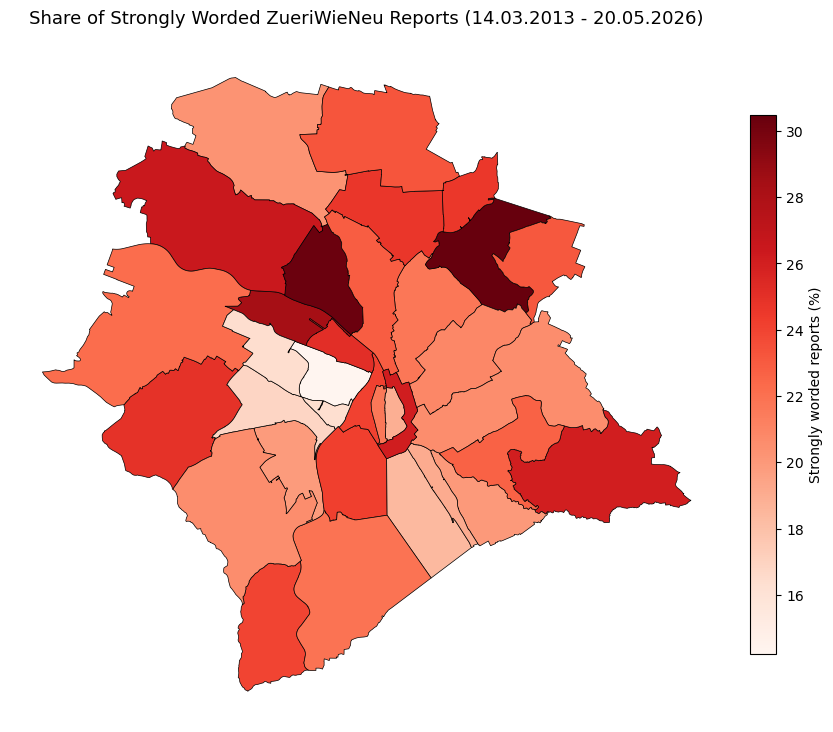

In [23]:
# Merge the strong wording shares back to the neighbourhood GeoDataFrame for mapping,
# filling missing shares with zero for neighbourhoods without reports
neighbourhood_strong_wording_gdf = neighbourhoods_gdf.merge(
    strong_wording_by_neighbourhood,
    on="neighbourhood",
    how="left", # Use left join to keep all neighbourhoods and identify those without reports with NaN shares
)

fig, ax = plt.subplots(figsize=(9, 8))

neighbourhood_strong_wording_gdf.plot(
    ax=ax,
    column="strong_wording_share_percent",
    cmap="Reds",
    legend=True,
    legend_kwds={
        "label": "Strongly worded reports (%)",
        "orientation": "vertical",
        "shrink": 0.7,
        "pad": 0.03,
    },
    edgecolor="black",
    linewidth=0.5,
    missing_kwds={"color": "lightgrey", "label": "No reports"}, # Show neighbourhoods without reports in light grey
)

ax.set_title(
    f"Share of Strongly Worded ZueriWieNeu Reports ({date_range_label})",
    fontsize=13,
)
ax.axis("off")
plt.tight_layout()
plt.show()

fig.savefig(OUTPUT_DIR / "strong_wording_map.png", dpi=300, bbox_inches="tight")

**Answer:** About 17.9% of mapped reports are flagged as strongly worded by the keyword proxy. The highest shares appear in Wipkingen (25.9%), Schwamendingen-Mitte (25.3%), and Escher Wyss (22.5%). This suggests some spatial clustering, but the measure should be interpreted carefully because it captures explicit words and punctuation rather than true sentiment. Interestingly, Langstrasse, which has the highest report count, has a low share of strongly worded reports (16.7%), while some lower-reporting neighbourhoods show higher shares. Schwammendingen-Mitte, which has the second-lowest report count, has the second-highest share of strongly worded reports, suggesting that a smaller number of reports may contain more emotional language in that area.

## Research Question 6: Has the Category Profile Changed over Time?

To compare categories across years, the notebook first counts reports by year and category, then converts those counts into yearly percentage shares. This makes years with different total report volumes comparable.


In [24]:
top_category_reports = reports[reports["service_name"].isin(common_categories)]

category_year = (
    top_category_reports.groupby(["year", "service_name"])
    .size()
    .reset_index(name="report_count")
)

# Treat missing year-category combinations as zero reports rather than
# missing data so category shares can be calculated consistently
category_year_pivot = category_year.pivot(  # Pivot the data to have years as rows and categories as columns
    index="year",
    columns="service_name",
    values="report_count",
).fillna(0)

# Convert counts to yearly shares so years with different reporting volumes
# remain directly comparable
category_year_share = category_year_pivot.div(
    category_year_pivot.sum(axis=1),
    axis=0,
) * 100

display(category_year_share.round(1).tail(10))

service_name,Abfall/Sammelstelle,Allgemein,Beleuchtung/Uhren,Grünflächen/Spielplätze,Signalisation/Lichtsignal,Strasse/Trottoir/Platz
year,,,,,,
2017,34.4,0.0,10.7,11.7,19.4,23.7
2018,35.2,0.0,11.4,9.6,22.2,21.5
2019,33.6,0.6,9.3,9.4,28.8,18.3
2020,45.0,8.2,8.2,12.1,14.9,11.6
2021,45.4,7.0,8.6,16.1,11.7,11.3
2022,49.5,7.7,6.7,10.2,13.6,12.3
2023,43.1,9.7,7.2,12.0,16.2,11.7
2024,48.7,10.0,6.3,9.9,16.0,9.2
2025,46.6,8.3,8.3,11.2,16.4,9.1


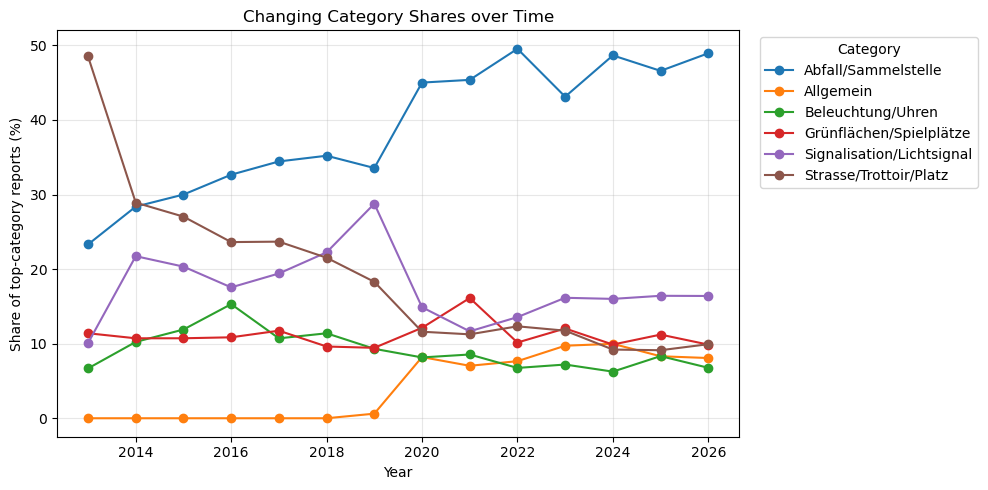

In [25]:
ax = category_year_share.plot(
    figsize=(10, 5),
    marker="o",
    title="Changing Category Shares over Time",
    xlabel="Year",
    ylabel="Share of top-category reports (%)",
)
ax.grid(True, alpha=0.3)
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left") # bbox_to_anchor and loc are used to position the legend outside the plot area
plt.tight_layout()
plt.show()


**Answer:** The category profile has changed. `Abfall/Sammelstelle` becomes much more dominant in recent years, reaching nearly half of top-category reports in 2022, 2024, and 2026. `Signalisation/Lichtsignal` is more prominent around 2019, while `Beleuchtung/Uhren` and `Strasse/Trottoir/Platz` generally account for smaller shares in the later years.


## Research Question 7: Which Neighbourhoods Have the Highest Report Density?

Raw counts can be misleading because neighbourhood polygons have different sizes. This section calculates reports per square kilometre using the polygon area in `EPSG:2056`, whose units are metres.


In [26]:
# .copy() is used to avoid modifying the original counts GeoDataFrame when calculating densities
neighbourhood_density_gdf = neighbourhood_counts_gdf.copy()

# EPSG:2056 uses metres, so dividing by 1'000'000 converts polygon area to square kilometres
neighbourhood_density_gdf["area_km2"] = neighbourhood_density_gdf.geometry.area / 1_000_000

# Normalise report counts by area to compare reporting intensity across
# neighbourhoods of different sizes
neighbourhood_density_gdf["reports_per_km2"] = (
    neighbourhood_density_gdf["report_count"] / neighbourhood_density_gdf["area_km2"]
)

# Rank neighbourhoods by report density
report_density_ranking = neighbourhood_density_gdf[
    ["neighbourhood", "report_count", "area_km2", "reports_per_km2"]
].sort_values("reports_per_km2", ascending=False) 

display(report_density_ranking.head(10).round(1))

,neighbourhood,report_count,area_km2,reports_per_km2
2,Langstrasse,6222,1.2,5134.5
27,Werd,1543,0.3,5102.5
24,Lindenhof,1139,0.3,4273.0
13,Rathaus,1480,0.4,4144.5
17,Sihlfeld,5277,1.7,3177.0
26,Gewerbeschule,2252,0.7,3083.7
15,City,1755,0.6,2949.3
30,Hochschulen,1430,0.6,2459.5
29,Hard,2887,1.4,2074.8
21,Wipkingen,3336,2.1,1587.0


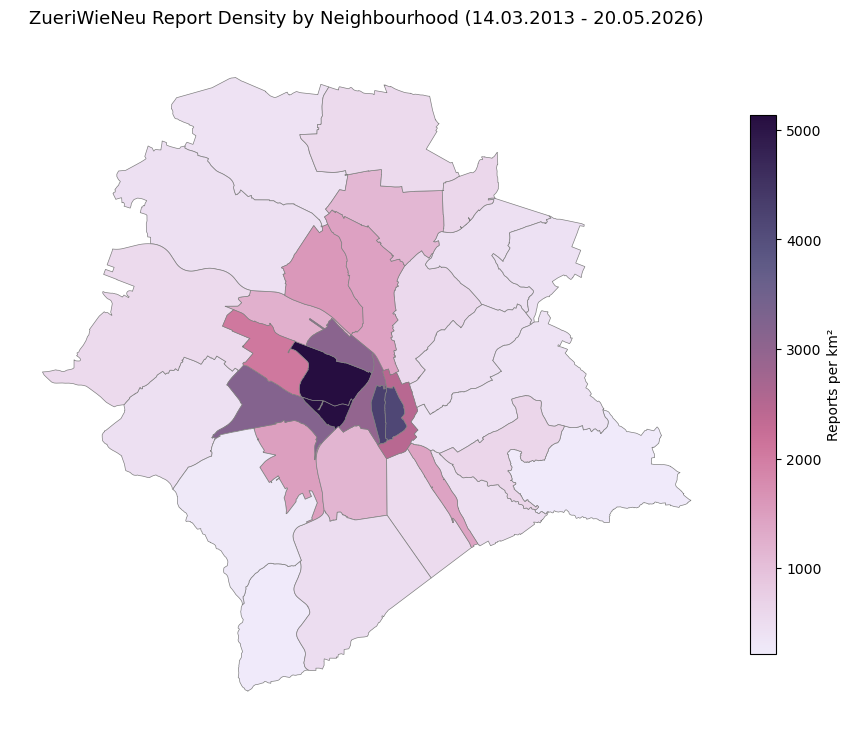

In [27]:
fig, ax = plt.subplots(figsize=(9, 8))

neighbourhood_density_gdf.plot(
    ax=ax,
    column="reports_per_km2",
    cmap=cm.acton_r, # _r is used to reverse the colormap
    legend=True,
    legend_kwds={
        "label": "Reports per km²",
        "orientation": "vertical",
        "shrink": 0.7,
        "pad": 0.03,
    },
    edgecolor="grey",
    linewidth=0.5,
)

ax.set_title(f"ZueriWieNeu Report Density by Neighbourhood ({date_range_label})", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

fig.savefig(OUTPUT_DIR / "report_density_map.png", dpi=300, bbox_inches="tight")

**Answer:** Langstrasse has the highest report density with about 5'134.5 reports per km², followed closely by Werd with 5'102.5 reports per km². Lindenhof and Rathaus also show high densities. This confirms that central neighbourhoods remain prominent even after adjusting raw counts by area. In general, the density patterns appear to follow highly frequented and central parts of the city. This may partly reflect the fact that these neighbourhoods are not only residential areas, but are also heavily used by commuters, tourists, shoppers, nightlife visitors, and workers, increasing both infrastructure usage and the likelihood of reporting problems.
